In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import kagglehub

In [2]:
df=pd.read_csv("/kaggle/input/datasets/shishirpuri/kamala-10-min-dataset/594 Water Level Inst from 2022-01-01 to 2026-06-15.csv")
df.head()

,dateTime (NPT),value (m)
0,2022-06-08 08:43:58,1.339599967
1,2022-06-08 08:45:00,1.339599967
2,2022-06-14 16:07:22,0
3,2022-06-14 17:26:56,1.61800003052
4,2022-06-15 14:09:12,1.61300003529


In [3]:
# Rename specific columns and update the original DataFrame
df.rename(columns={'dateTime (NPT)': 'dateTime', 'value (m)': 'value'}, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176626 entries, 0 to 176625
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   dateTime  176626 non-null  object
 1   value     176626 non-null  object
dtypes: object(2)
memory usage: 2.7+ MB


In [4]:
print(f"Total raw rows loaded: {len(df)}")

print("\nStep 2: Cleaning and formatting Timestamps...")
# Convert 'dateTime' to proper Datetime objects
df['dateTime'] = pd.to_datetime(df['dateTime'], errors='coerce')
df = df.dropna(subset=['dateTime'])

df.set_index('dateTime', inplace=True)
df.sort_index(inplace=True)

print("\nStep 3: Fixing Data Types (The Bug Fix) ...")
# THE FIX: Force the 'value' column to be numeric.
# errors='coerce' turns unconvertible garbage text into NaN instead of crashing.
# Note: Ensure the column name matches exactly what is in your CSV (e.g., 'value (m)' or 'value').
column_name = 'value' # CHANGE THIS to 'value (m)' if that is your exact header in the CSV.
df[column_name] = pd.to_numeric(df[column_name], errors='coerce')

print("\nStep 4: Applying 10-Minute Uniform Grid...")
# Now the .mean() function will work perfectly because it's calculating on floats, not text.
df_uniform = df.resample('10min').mean()

print("\n--- Process Complete ---")
print(f"Total rows in uniform grid: {len(df_uniform)}")
print(f"Start Date: {df_uniform.index.min()}")
print(f"End Date: {df_uniform.index.max()}")
print(f"Total missing intervals (NaNs) found in {column_name}: {df_uniform[column_name].isnull().sum()}")


Total raw rows loaded: 176626

Step 2: Cleaning and formatting Timestamps...

Step 3: Fixing Data Types (The Bug Fix) ...

Step 4: Applying 10-Minute Uniform Grid...

--- Process Complete ---
Total rows in uniform grid: 179499
Start Date: 2022-06-08 08:40:00
End Date: 2025-11-05 21:00:00
Total missing intervals (NaNs) found in value: 3252


In [5]:
df_uniform.tail()

,value
dateTime,
2025-11-05 20:20:00,1.618000
2025-11-05 20:30:00,1.617000
2025-11-05 20:40:00,1.620000
2025-11-05 20:50:00,1.617667
2025-11-05 21:00:00,1.617000


In [6]:
print("Step 1: Analyzing Outliers (Garbage Values)")
# Count how many weird values exist
outlier_mask = (df_uniform['value'] > 20) | (df_uniform['value'] < 0)
total_outliers = outlier_mask.sum()
print(f"Total Outliers found (Height > 20m or < 0m): {total_outliers}")

# ---------------------------------------------------------
# STEP 2: THE "SMART FIX" (Replacing outliers with NaN temporarily)
# ---------------------------------------------------------
# Hami outlers lai paila NaN banauchau
df_uniform.loc[outlier_mask, 'value'] = np.nan

# ---------------------------------------------------------
# STEP 3: LOCAL INTERPOLATION (Fixing small glitches ONLY)
# ---------------------------------------------------------
print("\nStep 3: Applying Smart Local Smoothing...")
# Interpolate method='linear' le agadi-pachadi ko line jodhcha.
# limit=4 ko matlab: yadi lagatar 4 ota (40 mins) samma matra NaN cha bhane teslai fill garne.
# Yadi timile vanya jasto 30-35 ota lagatar NaN cha bhane, yesle fill gardaina!
df_uniform['value'] = df_uniform['value'].interpolate(method='linear', limit=6)

# Aba check garau kati wata NaN baki chan (jun lamo errors thiyo)
remaining_nans = df_uniform['value'].isnull().sum()
print(f"Small glitches fixed successfully without breaking sequences!")
print(f"Remaining large errors (which will break sequences during chunking): {remaining_nans}")

# ---------------------------------------------------------
# STEP 4: VERIFY CLEAN DATA
# ---------------------------------------------------------
print(f"\nNew Clean Max Height: {df_uniform['value'].max():.2f} meters")
print(f"New Clean Min Height: {df_uniform['value'].min():.2f} meters")

Step 1: Analyzing Outliers (Garbage Values)
Total Outliers found (Height > 20m or < 0m): 4680

Step 3: Applying Smart Local Smoothing...
Small glitches fixed successfully without breaking sequences!
Remaining large errors (which will break sequences during chunking): 6581

New Clean Max Height: 5.46 meters
New Clean Min Height: 0.00 meters


In [7]:
# ---------------------------------------------------------
# STEP 1: THE CHUNKING ALGORITHM
# ---------------------------------------------------------
def split_into_valid_chunks(df, column_name='value', min_length=36):
    """
    NaN aayeko thau ma data lai break garchha.
    Yadi chunk ko length 36 (6 hours) bhanda sano cha bhane discard garcha.
    """
    valid_chunks = []
    current_chunk = []
    
    # Iterate through the DataFrame values
    values = df[column_name].values
    
    for val in values:
        if pd.notna(val):
            # Yadi number ho bhane, current chunk ma jodne
            current_chunk.append(val)
        else:
            # Yadi NaN aayo bhane, gap bhetthyo!
            # Paila check garne current_chunk lamo cha ki chaina
            if len(current_chunk) > min_length:
                valid_chunks.append(np.array(current_chunk))
            # Current chunk lai khali (reset) garne next valid block ko lagi
            current_chunk = []
            
    # Loop sakiye pachi last ko bacheko chunk check garne
    if len(current_chunk) > min_length:
        valid_chunks.append(np.array(current_chunk))
        
    return valid_chunks

# Hamro lag time 36 ho (6 hours)
time_step = 36 
print("Running Chunking Algorithm...")
chunks = split_into_valid_chunks(df_uniform, column_name='value', min_length=time_step)

print(f"\n✅ Success! Data split into {len(chunks)} completely safe, continuous chunks.")

# ---------------------------------------------------------
# STEP 2: LETS SEE WHAT A CHUNK LOOKS LIKE
# ---------------------------------------------------------
# Paila 5 wata chunks ko length herau
print("\nLengths of the first 5 chunks:")
for i in range(min(5, len(chunks))):
    print(f"Chunk {i+1}: {len(chunks[i])} data points ({len(chunks[i])*10/60:.1f} hours of continuous data)")

total_valid_points = sum(len(c) for c in chunks)
print(f"\nTotal safe data points we rescued: {total_valid_points}")
print(f"Total points discarded (NaNs + tiny chunks): {len(df) - total_valid_points}")

Running Chunking Algorithm...

✅ Success! Data split into 58 completely safe, continuous chunks.

Lengths of the first 5 chunks:
Chunk 1: 91 data points (15.2 hours of continuous data)
Chunk 2: 46 data points (7.7 hours of continuous data)
Chunk 3: 200 data points (33.3 hours of continuous data)
Chunk 4: 113 data points (18.8 hours of continuous data)
Chunk 5: 35740 data points (5956.7 hours of continuous data)

Total safe data points we rescued: 171843
Total points discarded (NaNs + tiny chunks): 4783


In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM,Dropout
import matplotlib.pyplot as plt
print("Step 1: Normalizing the Data...")
# Paila sabai chunks lai ekai thau ma jodera Global Min ra Max patta lagaune
all_data_combined = np.concatenate(chunks).reshape(-1, 1)

# Scaler define garne (0 to 1) ra fit garne
scaler = MinMaxScaler(feature_range=(0, 1))
scaler.fit(all_data_combined)

# Aba harek chunk lai scale (transform) garne
scaled_chunks = [scaler.transform(chunk.reshape(-1, 1)) for chunk in chunks]
print("✅ Normalization Complete!")

2026-06-25 15:16:46.282587: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782400606.635920      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782400606.748666      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782400607.663919      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782400607.663988      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782400607.663991      16 computation_placer.cc:177] computation placer alr

Step 1: Normalizing the Data...
✅ Normalization Complete!


In [9]:
# ---------------------------------------------------------
# STEP 2: LETS CREATE THE SLIDING WINDOWS (X and y)
# ---------------------------------------------------------
print("\nStep 2: Creating X (Inputs) and y (Targets) from scaled chunks...")
time_step = 36 # 6 hours history
X_list, y_list = [], []

for chunk in scaled_chunks:
    # Harek chunk ko length bata time_step ghatauda jati bancha, teti wata window bancha
    for i in range(len(chunk) - time_step):
        X_list.append(chunk[i:(i + time_step), 0]) # Past 36 steps
        y_list.append(chunk[i + time_step, 0])     # Next 1 step (Target)

X = np.array(X_list)
y = np.array(y_list)

# LSTM lai data 3D shape ma chahincha: [samples, time_steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)

print(f"Total Sequences Created: {len(X)}")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")


Step 2: Creating X (Inputs) and y (Targets) from scaled chunks...
Total Sequences Created: 169755
Shape of X: (169755, 36, 1)
Shape of y: (169755,)


In [10]:
# ---------------------------------------------------------
# STEP 3: TRAIN / TEST SPLIT (Chronological)
# ---------------------------------------------------------
print("\nStep 3: Splitting into 80% Training and 20% Testing...")
split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")


Step 3: Splitting into 80% Training and 20% Testing...
Training set size: 135804
Testing set size: 33951


In [11]:
# ---------------------------------------------------------
# STEP 4: DESIGNING THE LSTM MODEL
# ---------------------------------------------------------
print("\nStep 4: Building the LSTM Architecture...")
model = Sequential()

# Layer 1 (LSTM le pattern sikcha)
model.add(LSTM(50, return_sequences=True, input_shape=(time_step, 1)))
model.add(Dropout(0.2)) # Overfitting garna bata rokcha

# Layer 2 (Deep learning)
model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.2))

# Final Output Layer (1 number predict garne)
model.add(Dense(25))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_squared_error')
print("✅ Model Architecture Ready!")


Step 4: Building the LSTM Architecture...
✅ Model Architecture Ready!


2026-06-25 15:17:05.666162: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
# ---------------------------------------------------------
# STEP 5: TRAINING THE MODEL
# ---------------------------------------------------------
print("\nStep 5: Training Started (Running 5 Epochs for initial test)...")
# Note: 175k data cha, so 1 epoch run huna kei time lagna sakcha!
history = model.fit(X_train, y_train, 
                    validation_data=(X_test, y_test), 
                    epochs=5, 
                    batch_size=64, 
                    verbose=1)

print("\n✅ Training Complete!")


Step 5: Training Started (Running 5 Epochs for initial test)...
Epoch 1/5
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 85s 38ms/step - loss: 2.5617e-04 - val_loss: 8.3198e-05
Epoch 2/5
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 84s 40ms/step - loss: 1.3229e-04 - val_loss: 5.7117e-05
Epoch 3/5
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 84s 40ms/step - loss: 1.1953e-04 - val_loss: 6.7634e-05
Epoch 4/5
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 86s 40ms/step - loss: 1.1770e-04 - val_loss: 5.5865e-05
Epoch 5/5
2122/2122 ━━━━━━━━━━━━━━━━━━━━ 84s 40ms/step - loss: 1.1280e-04 - val_loss: 7.1268e-05

✅ Training Complete!


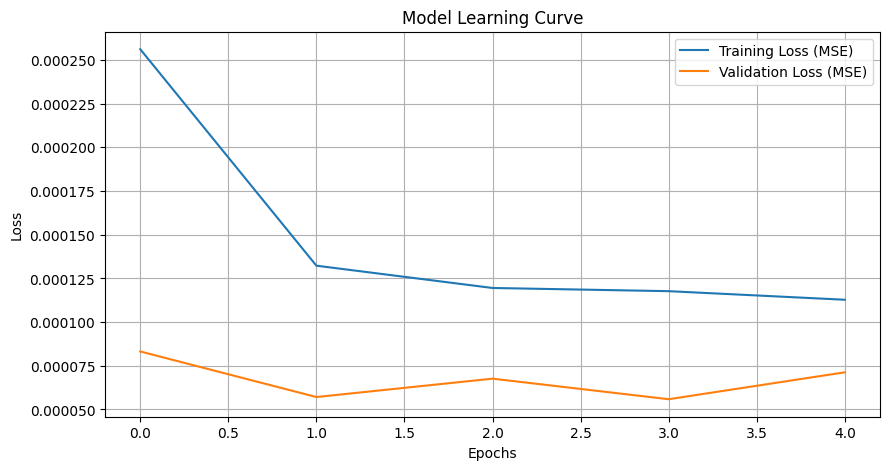

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Model Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Step 1: Generating Predictions on Test Set...
1061/1061 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step
Step 2: Inverse Transforming (0-1 back to Real Meters)...

--- MODEL PERFORMANCE (REAL WORLD METRICS) ---
RMSE (Root Mean Squared Error): 0.0372 meters
MAE (Mean Absolute Error)     : 0.0208 meters
(Matlab: Timro model le average ma 2.1 cm ko matra mistake garcha!)

Step 4: Plotting Actual vs Predicted...


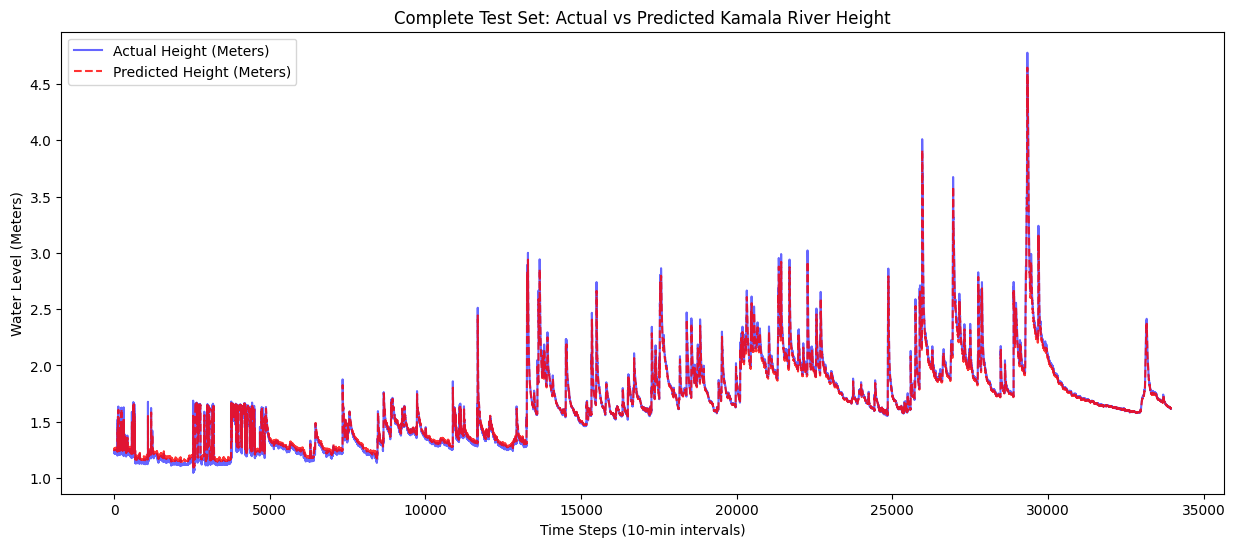

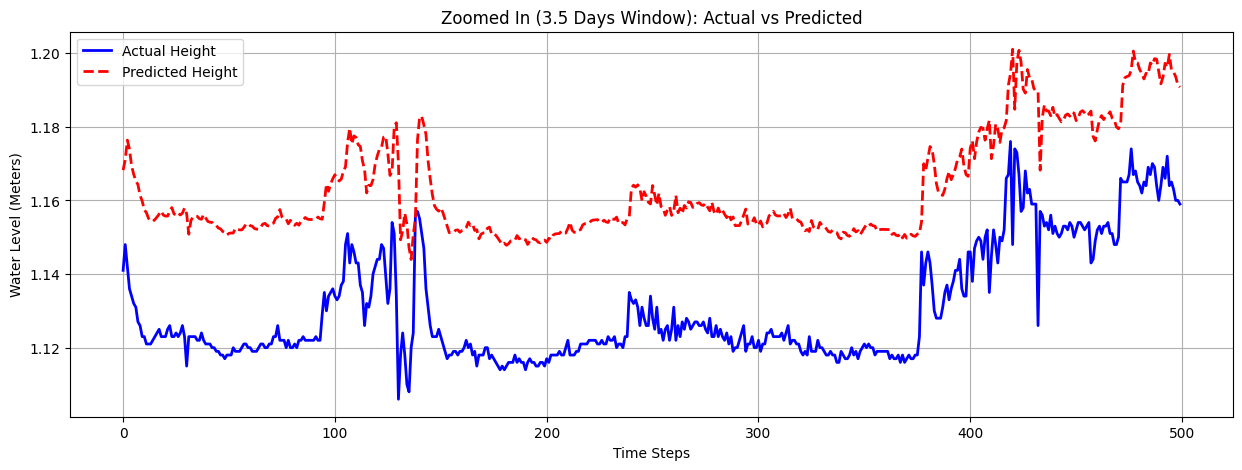

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

print("Step 1: Generating Predictions on Test Set...")
# Test set ma bholi ko height predict garne
predictions = model.predict(X_test)

print("Step 2: Inverse Transforming (0-1 back to Real Meters)...")
# Model le 0-1 scale ma deko prediction lai actual meters ma convert garne
predictions_real = scaler.inverse_transform(predictions)
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

# ---------------------------------------------------------
# STEP 3: CALCULATING ACCURACY METRICS (IN METERS)
# ---------------------------------------------------------
# RMSE (Root Mean Squared Error) ra MAE (Mean Absolute Error) nikalne
rmse = math.sqrt(mean_squared_error(y_test_real, predictions_real))
mae = mean_absolute_error(y_test_real, predictions_real)

print("\n--- MODEL PERFORMANCE (REAL WORLD METRICS) ---")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f} meters")
print(f"MAE (Mean Absolute Error)     : {mae:.4f} meters")
print(f"(Matlab: Timro model le average ma {mae*100:.1f} cm ko matra mistake garcha!)")

# ---------------------------------------------------------
# STEP 4: PLOTTING THE RESULTS
# ---------------------------------------------------------
print("\nStep 4: Plotting Actual vs Predicted...")

# Plot 1: Overall Test Data (Sabai 35,000+ points)
plt.figure(figsize=(15, 6))
plt.plot(y_test_real, color='blue', label='Actual Height (Meters)', alpha=0.6)
plt.plot(predictions_real, color='red', label='Predicted Height (Meters)', alpha=0.8, linestyle='dashed')
plt.title('Complete Test Set: Actual vs Predicted Kamala River Height')
plt.xlabel('Time Steps (10-min intervals)')
plt.ylabel('Water Level (Meters)')
plt.legend()
plt.show()

# Plot 2: Zoomed-in View (Because Plot 1 might look like a crowded blob)
# Hami jamma 500 steps (approx 3.5 days) ko slice herchau jaha ali fluctuation cha
start_zoom = 2000 # Random start point, timi aafai change garera farak thau herna sakchau
end_zoom = 2500

plt.figure(figsize=(15, 5))
plt.plot(y_test_real[start_zoom:end_zoom], color='blue', label='Actual Height', linewidth=2)
plt.plot(predictions_real[start_zoom:end_zoom], color='red', label='Predicted Height', linewidth=2, linestyle='dashed')
plt.title('Zoomed In (3.5 Days Window): Actual vs Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Water Level (Meters)')
plt.legend()
plt.grid(True)
plt.show()